In [20]:
from cd.data.datasets import *
from cd.utils.windows import *
from cd.utils.plotting import *
from cd.utils.stats import mmd_squared
from cd.algs.kernels.spatial_kernel import *
from cd.algs.kernels.temporal_kernel import *

import matplotlib.pyplot as plt

In [123]:
win = 100
x_tr, x_te, y_true, _ = load_experiment('humanoid', trim=True, normalize=False, win=win)
x_tr = strided_window_view(x_tr, window=x_te.shape[1], stride=100).reshape(-1, x_te.shape[1], x_tr.shape[-1])
x_tr.shape, x_te.shape, y_true.shape

((2700, 100, 45), (996, 100, 45), (996,))

In [3]:
x_te, y_true = stratified_subsample(x_te, y_true, n_eps=100)

In [4]:
gammas = fit_gammas(x_tr)
def spatial_kernel(X1, X2):
        return humanoid_composite_kernel(X1, X2, **gammas)

In [5]:
gammas

{'gamma_r': np.float32(73.16423),
 'gamma_theta': np.float32(8.148011),
 'gamma_v': np.float32(0.0020621119)}

<Axes: >

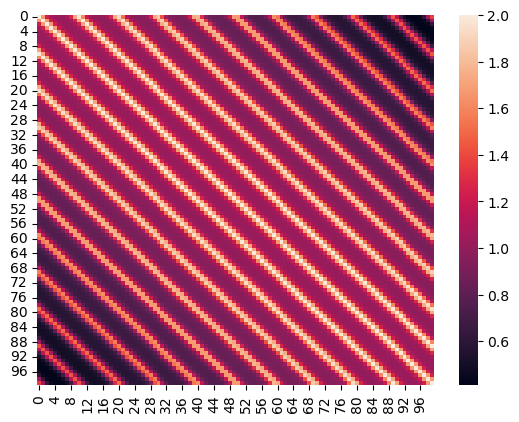

In [130]:
k = RBFKernel(length_scale=.7) + PeriodicKernel(period=0.1, length_scale=.7)
K_t = k(np.linspace(0, 1, x_tr.shape[1]))
sns.heatmap(K_t)

In [127]:
K = cross_covariance_gram(x_te, K_t=K_t, spatial_kernel_fn=spatial_kernel)
mmd_squared(K, y_true)

289.2623244115846

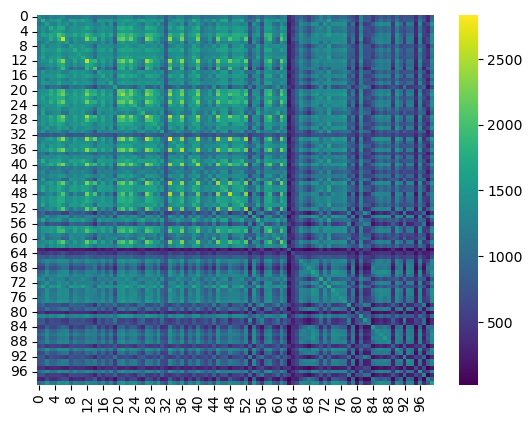

In [128]:
plot_gram(K, y_true)

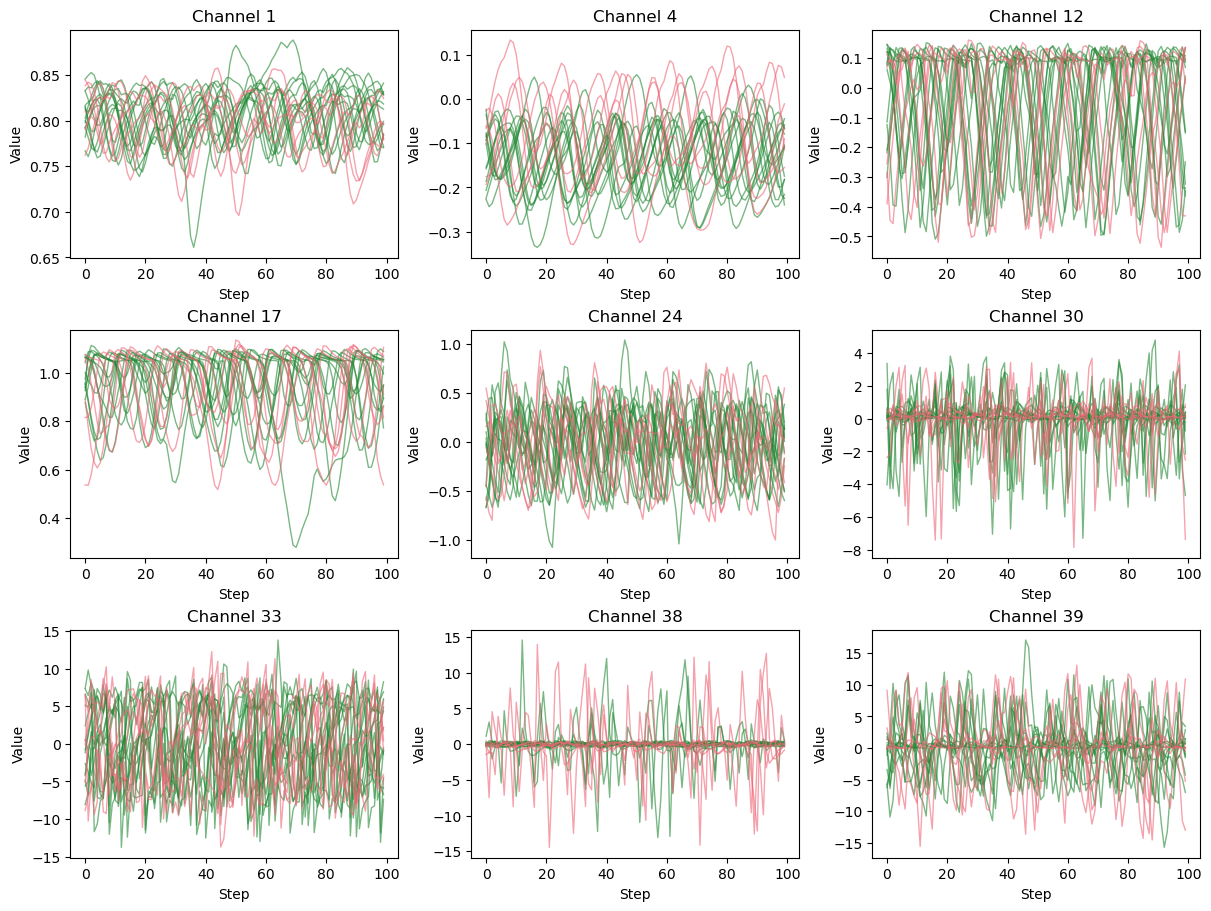

In [150]:
plot_channels(x_te, y_true);

In [13]:
from sklearn.decomposition import KernelPCA
from cd.algs.kernels.temporal_kernel import *

In [32]:
def transform(x):
    z = np.stack([KernelPCA(n_components=10, kernel=spatial_kernel).fit_transform(xi) for xi in x])
    z = MaternKernel(n_steps=50, rank=10, length_scale=1/50, order=0).transform(z)
    return z

In [33]:
z_tr = transform(x_tr)

In [35]:
z_te = transform(x_te)

In [36]:
z_te.shape

(1000, 10, 10)

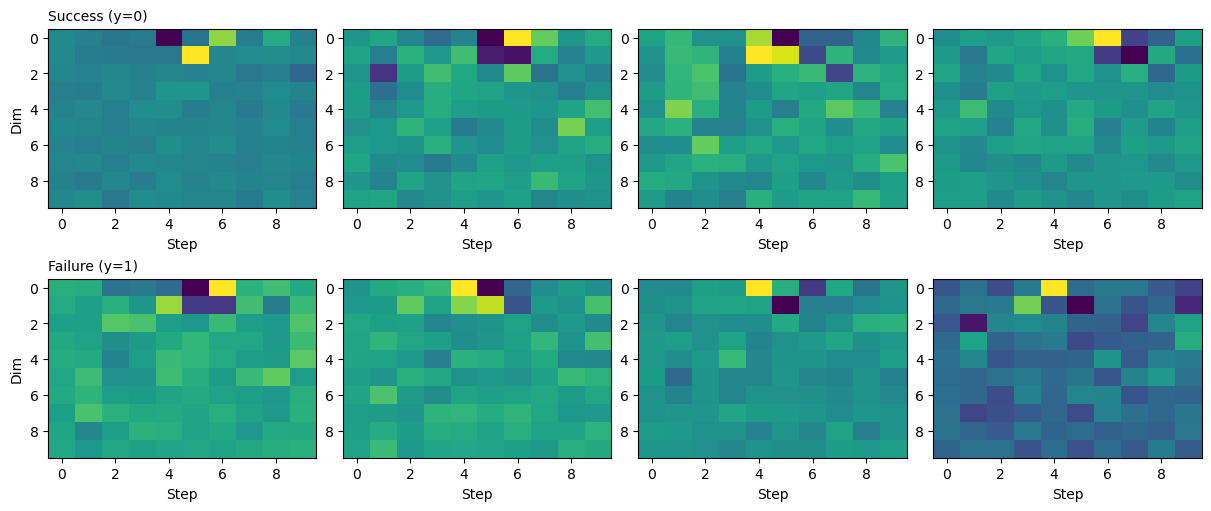

In [41]:
plot_heatmaps(z_te, y_true);

## Classification performance

In [81]:
from cd.utils.plotting import plot_hists
from cd.algs.kernels.trajectory_kernels import *
from cd.algs.kern_cd import KernCD

In [93]:
win = 100
x_tr, x_te, y_true, _ = load_experiment('hopper', trim=True, normalize=True, win=win)
x_tr = strided_window_view(x_tr, window=x_te.shape[1], stride=100).reshape(-1, x_te.shape[1], x_tr.shape[-1])
x_tr.shape, x_te.shape, y_true.shape

((2700, 100, 11), (1000, 100, 11), (1000,))

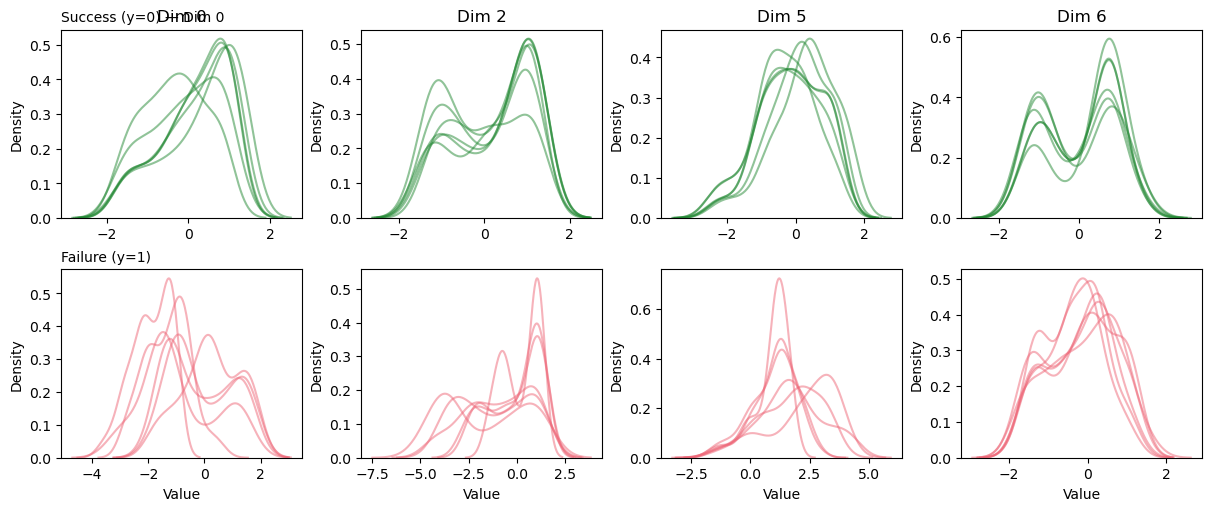

In [94]:
plot_hists(x_te, y_true, most_different=True);

In [95]:
model = KernCD(SumKernel(gamma=0.1), reg=1e-5).fit(x_tr[::3])

In [96]:
y_pred = model.predict(x_te)

In [87]:
from sklearn.metrics import roc_auc_score

<Axes: ylabel='Density'>

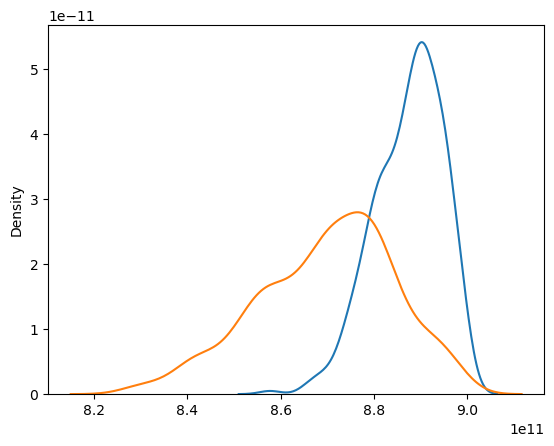

In [90]:
sns.kdeplot(y_pred[y_true])
sns.kdeplot(y_pred[~y_true])

In [92]:
roc_auc_score(y_true, y_pred)

0.8615162686327937

## RFF approximation

In [349]:
from cd.algs.kernels.trajectory_kernels import RFFMeanKernel
from cd.algs.kernels.spatial_kernel import fit_rbf_gamma

In [367]:
win = 100
x_tr, x_te, y_true, _ = load_experiment('hopper', trim=True, normalize=True, win=win)
#x_tr = strided_window_view(x_tr, window=x_te.shape[1], stride=100).reshape(-1, x_te.shape[1], x_tr.shape[-1])
x_tr.shape, x_te.shape, y_true.shape

((300, 900, 11), (1000, 100, 11), (1000,))

In [368]:
gamma = fit_rbf_gamma(x_tr)
gamma

np.float32(0.04479049)

In [369]:
x_tr.shape

(300, 900, 11)

In [370]:
x_tr[::30].shape

(10, 900, 11)

In [354]:
X_sub = x_tr[:, :100]

K_exact = sum_kernel(X_sub, gamma=gamma) / X_sub.shape[1]**2  # normalize to mean kernel for comparison

for m in [64, 128, 256, 512, 1024, 2048]:
    kern = RFFMeanKernel(gamma=gamma, n_components=m)
    kern.fit(X_sub)
    K_rff = kern(X_sub)
    rel_err = np.linalg.norm(K_exact - K_rff) / np.linalg.norm(K_exact)
    print(f"m={m:5d}  rel_err={rel_err:.4f}")



KeyboardInterrupt: 

In [371]:
model = KernCD(RFFMeanKernel(gamma=gamma, n_components=256), reg=1e-5).fit(x_tr)

In [372]:
y_score = np.log(model.predict(x_te))

In [373]:
y_score.shape

(1000,)

0.9874343715760191

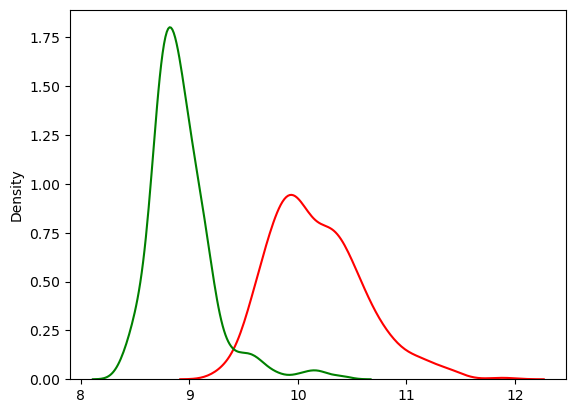

In [374]:
sns.kdeplot(y_score[y_true], color='red')
sns.kdeplot(y_score[~y_true], color='green')
roc_auc_score(y_true, y_score)